In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import weatherdata as wd

## Retrieving

In [2]:
# import retrieve_modelled_data as ret
# filesList = ret.get_list()
# data = ret.main(filesList, 2, output_dir='/nird/projects/NS9873K/emile/unseen-storm-forecasts/2_days_event_def/data')

In [3]:
data = xr.open_dataarray(
    'data/retrieved-full-2.nc'
)

In [4]:
# import preprocess as ppro
# processed = ppro.maximize(data)
# processed.to_netcdf('data/processed.nc')
# maxs = processed.max(dim="time")
# maxs.to_netcdf('data/maxs.nc')

In [5]:
processed = xr.open_dataset('data/processed.nc')
maxs = xr.open_dataarray('data/maxs.nc')

In [6]:
# import retrieve_rea_data as ret_rea
# rea_data = wd.sum_over_time(
#     ret_rea.main(ret_rea.fileList),
#     span=2,
#     edges=False
# )
# rea_data.to_netcdf('data/retrieved-rea-2.nc')

In [7]:
rea_data = xr.open_dataarray('data/retrieved-rea-2.nc')

In [8]:
# import rea_maxs
# era5 = rea_maxs.main(rea_data)
# era5.to_netcdf('data/processed-rea-2.nc')

In [9]:
era5 = xr.open_dataarray('data/processed-rea-2.nc')

## Tests

In [10]:
import test_fidelity as fid
import test_stability as stab
import test_independence as ind

In [11]:
# maxs_aug = maxs.sel(date=maxs.month==8)
# maxs_aug.to_netcdf('august/maxs-aug.nc')
# processed_aug = processed.sel(date=processed.month==8)
# processed_aug.to_netcdf('august/processed-aug.nc')

In [12]:
processed_aug = xr.open_dataarray('august/processed-aug.nc')
maxs_aug = xr.open_dataarray('august/maxs-aug.nc')

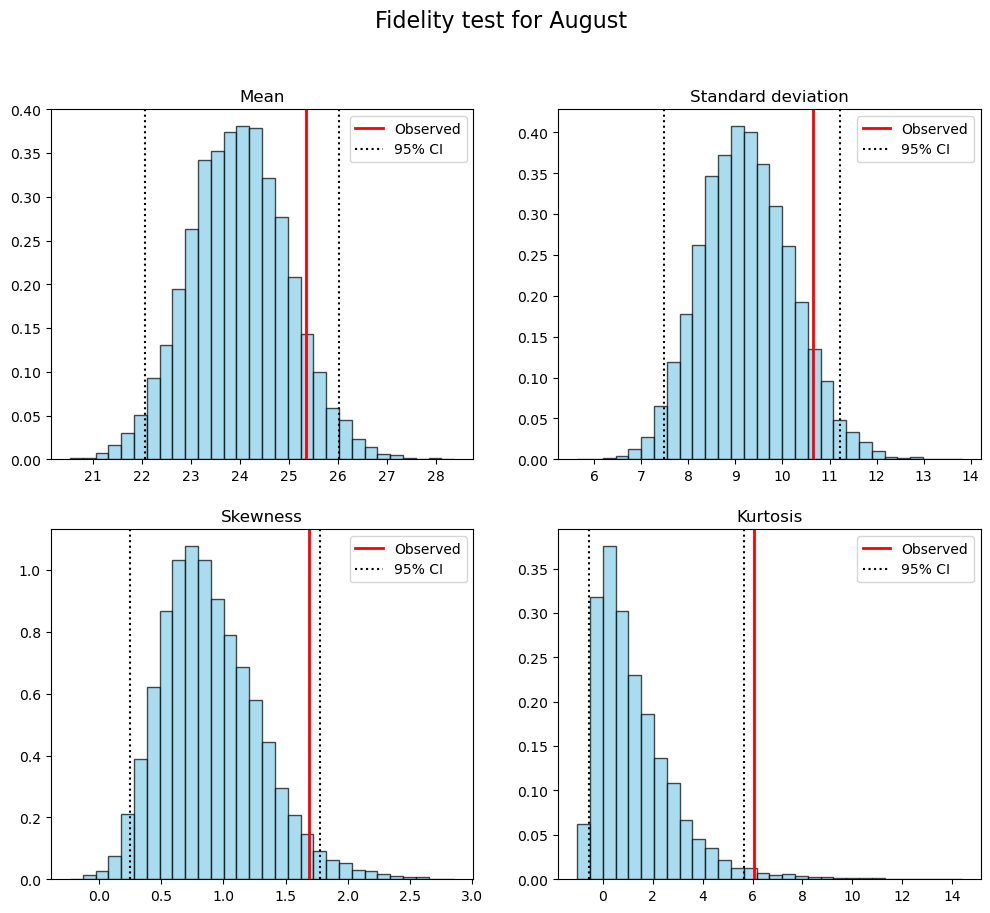

In [13]:
rea, mod = fid.main("august/maxs-aug.nc", "data/processed-rea-2.nc")
fid.plot(rea, mod, "august/raw", "August", show=True)

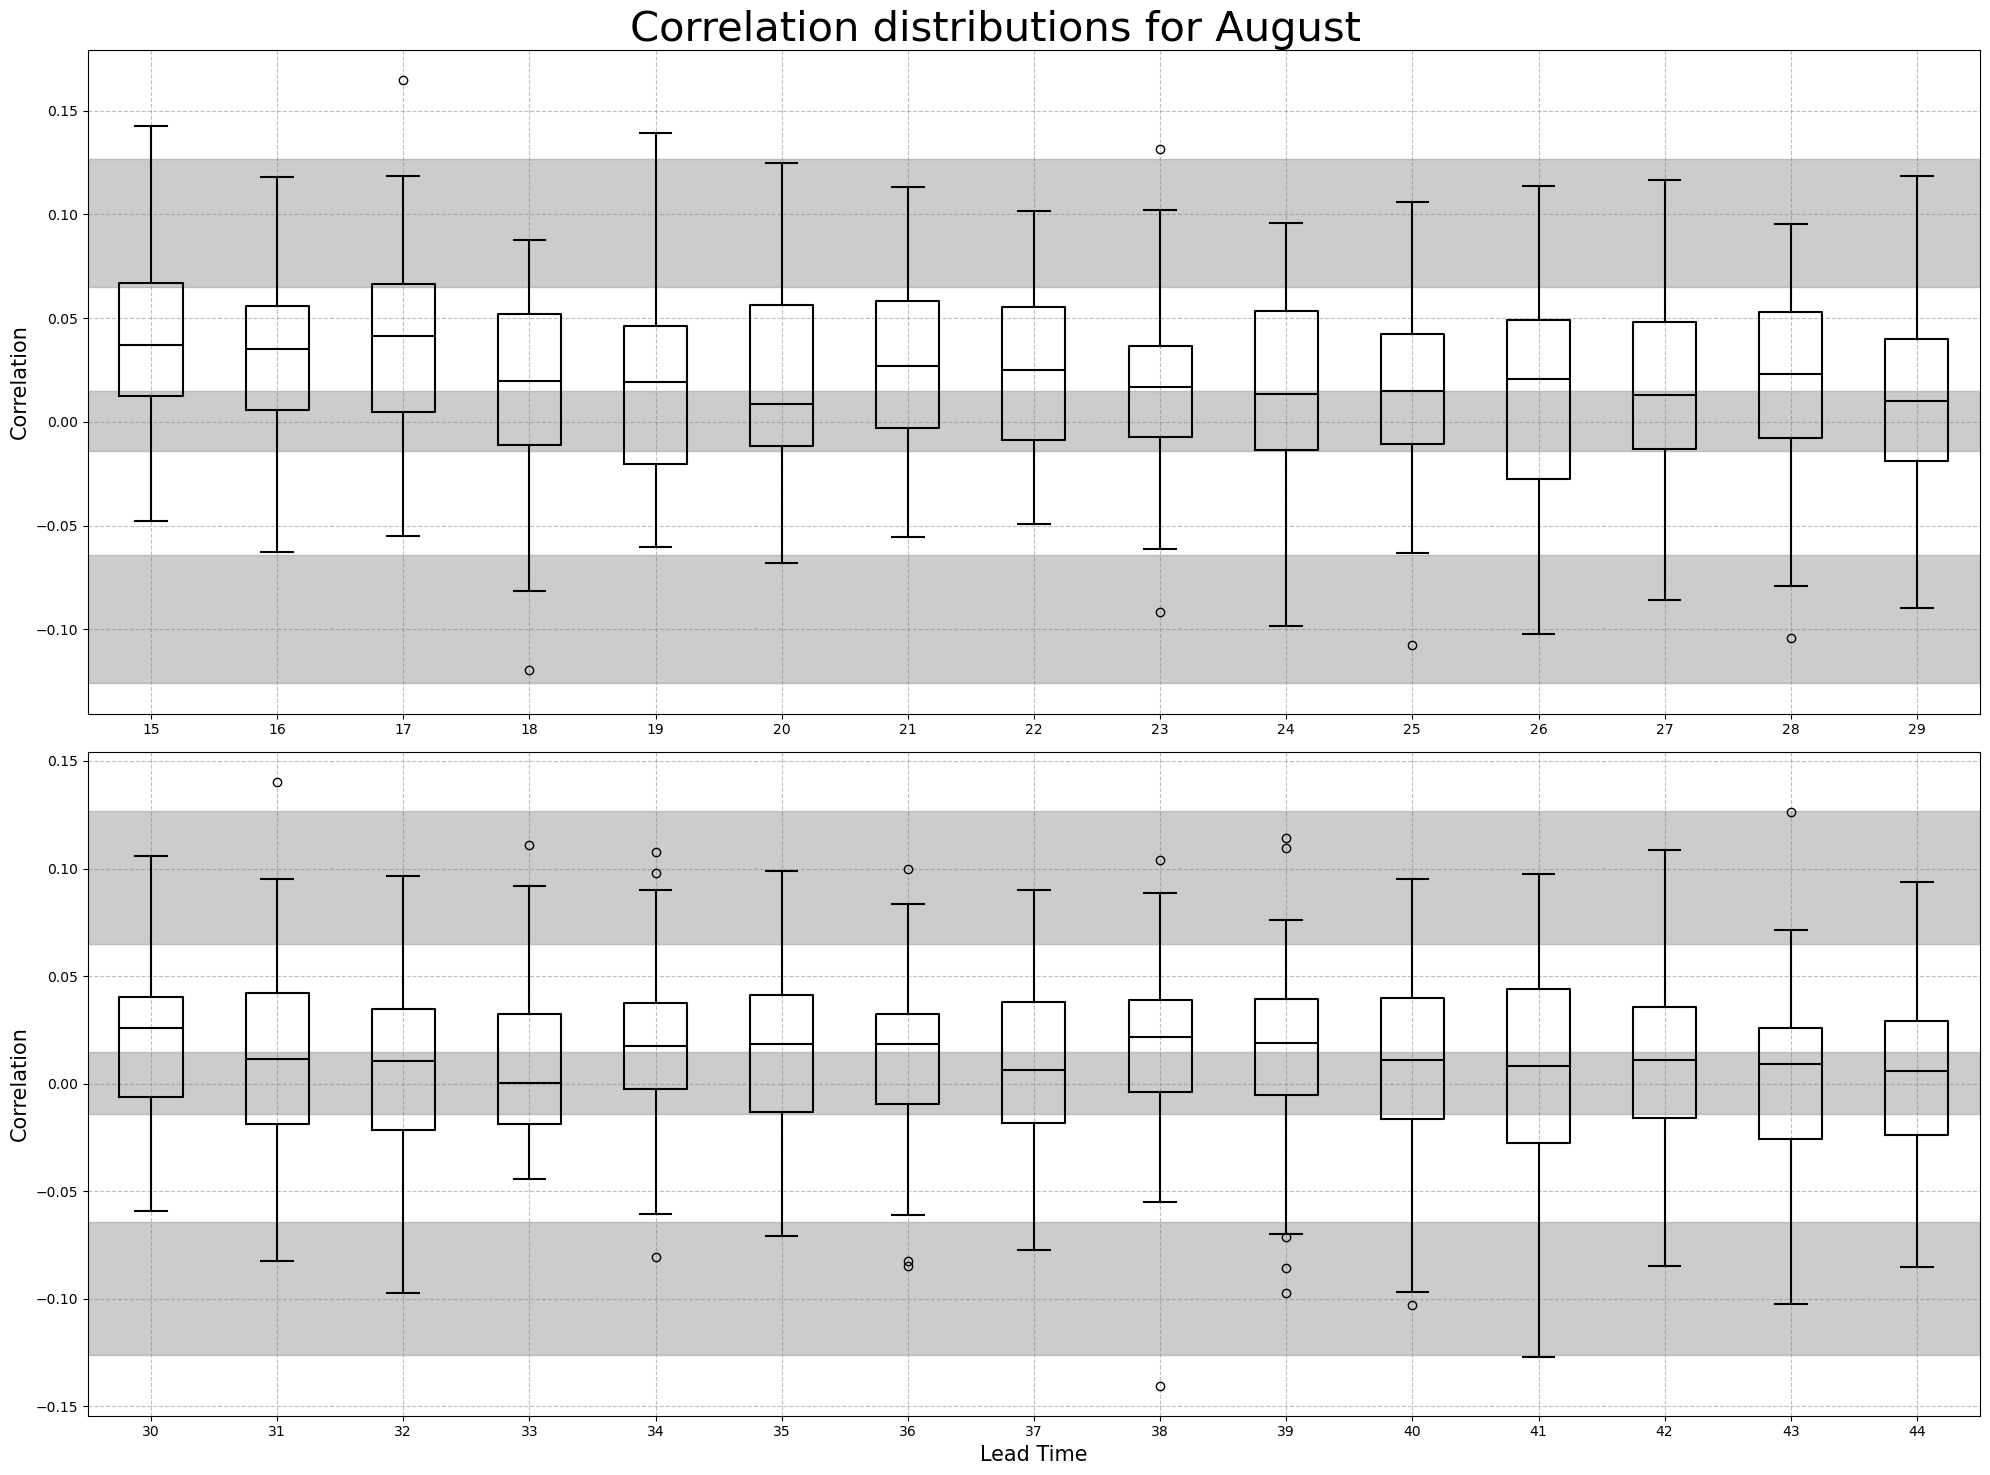

In [14]:
correl, interv = ind.correlation(processed_aug)
ind.plot_correlations(correl, interv, "august/raw", show=True)

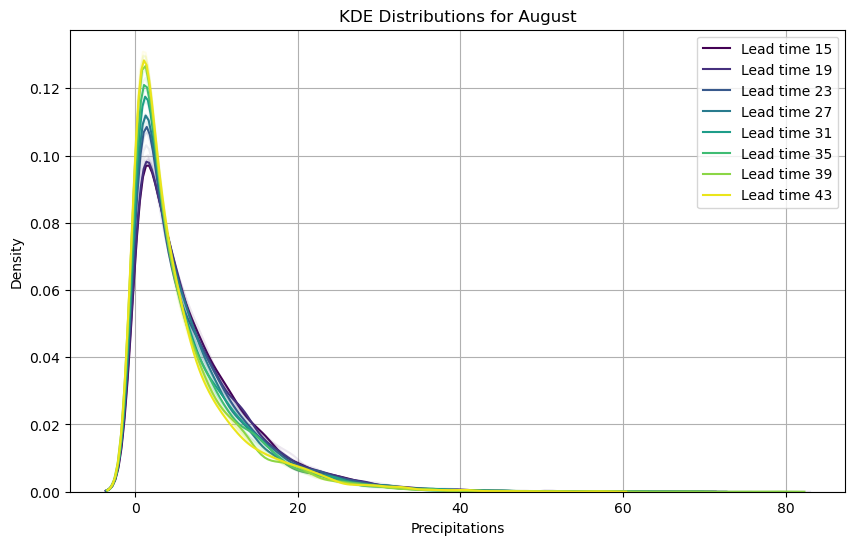

In [15]:
stab.plot_kde_distributions(processed_aug, "august/raw", show=True)

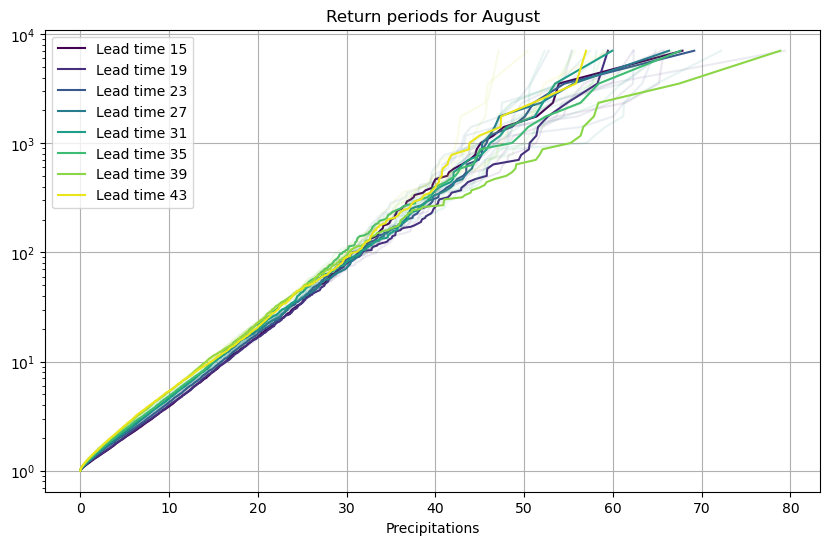

In [17]:
stab.plot_return_period(processed_aug, "august/raw", show=True)